# PU experiments

In [1]:
import os
import pandas as pd
import numpy as np
from data.datasets import get_pd_dataset,prepare_and_split_data
from data.dataset_helpers import SAR
from config import CONFIG
import matplotlib.pyplot as plt
from classifiers.TM_log_reg import TwoModelLogReg
from classifiers.classic_log_reg import ClassicLogReg
from classifiers.naive_log_reg import NaiveLogReg
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,classification_report
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

import seaborn as sns
import numpy.random as rng
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import warnings
from sklearn.exceptions import ConvergenceWarning
import json

In [2]:
datasets = ["mock","diabetes","breastcancer","mnist"]

In [3]:
models = {
    "classic": ClassicLogReg(),
    "naive": NaiveLogReg(),
    "two_model": TwoModelLogReg()
}

In [4]:
def describe_dataset(data,name):
    print(f"\n \nDataset: {name} \n")
    n_sampels = data.shape[0]
    n_features = data.shape[1]-1    
    class_balance = data["target"].sum()/n_sampels
    print(f"Number of samples: {n_sampels}")
    print(f"Number of features: {n_features}")
    print(f"Class balance (positive class): {class_balance:.2f} \n")
    X_train,X_test,y_train,y_test = train_test_split(data.drop(columns=["target"]), data["target"], test_size=0.2, random_state=42)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    clf = LogisticRegression(verbose=0)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(pd.DataFrame(classification_report(y_test, y_pred,output_dict=True)).T)


for dataset in datasets:
    data = get_pd_dataset(name=dataset)
    describe_dataset(data,name=dataset)



 
Dataset: mock 

Number of samples: 3315
Number of features: 4
Class balance (positive class): 0.02 

              precision    recall  f1-score     support
0              0.978852  0.998459  0.988558  649.000000
1              0.000000  0.000000  0.000000   14.000000
accuracy       0.977376  0.977376  0.977376    0.977376
macro avg      0.489426  0.499230  0.494279  663.000000
weighted avg   0.958182  0.977376  0.967684  663.000000

 
Dataset: diabetes 

Number of samples: 768
Number of features: 8
Class balance (positive class): 0.35 

              precision    recall  f1-score     support
0              0.812500  0.787879  0.800000   99.000000
1              0.637931  0.672727  0.654867   55.000000
accuracy       0.746753  0.746753  0.746753    0.746753
macro avg      0.725216  0.730303  0.727434  154.000000
weighted avg   0.750154  0.746753  0.748167  154.000000

 
Dataset: breastcancer 

Number of samples: 569
Number of features: 30
Class balance (positive class): 0.63 

     

# label frequency

In [73]:
path = "/Users/cas/Documents/naive_pu/EXPERIMENTS/c/1.0_mnist_oracle_9.pkl"
df = pd.read_pickle(path)
df["accuracy"].unique()
df = df[df["c"]<=1]
df = df[df["c"]>0.8]
df_9 = df[df["model"]!="oracle"].copy()

path = "/Users/cas/Documents/naive_pu/EXPERIMENTS/c/0.8_mnist_oracle_9.pkl"
df = pd.read_pickle(path)
df["accuracy"].unique()
df = df[df["c"]<=0.8]
df_8 = df[df["model"]!="oracle"].copy()
df = pd.concat([df_8,df_9])

In [74]:
mock = df[df["dataset"]=="mock"].copy()
diabetes = df[df["dataset"]=="diabetes"].copy()
breastcancer = df[df["dataset"]=="breastcancer"].copy()
mnist = df[df["dataset"]=="mnist"].copy() 
print(f"Shapes {mock.shape}, {diabetes.shape}, {breastcancer.shape}, {mnist.shape}")  

Shapes (300, 13), (300, 13), (300, 13), (300, 13)


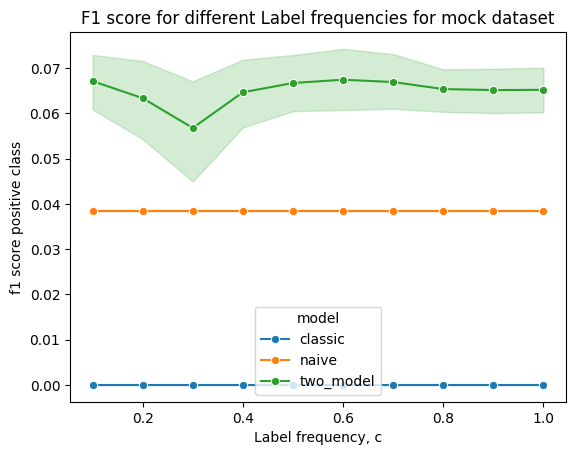

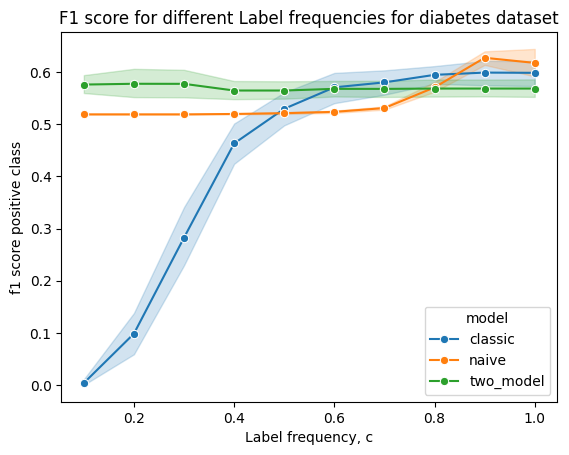

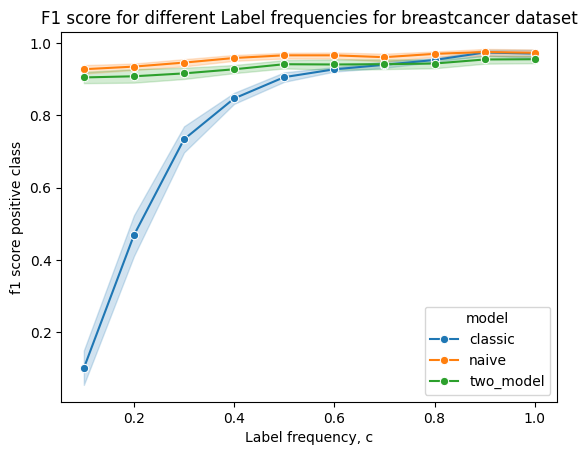

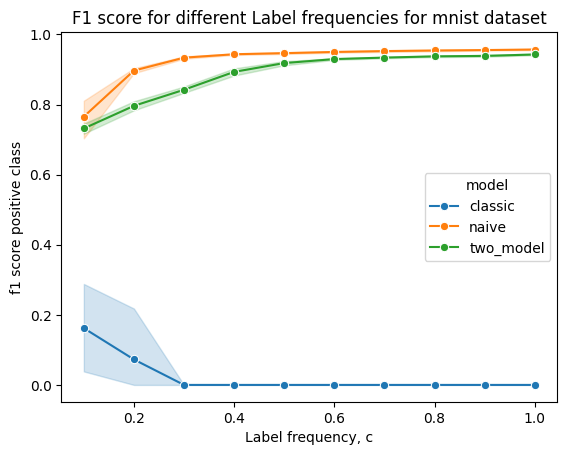

In [76]:


for name,data in zip(datasets,[mock,diabetes,breastcancer,mnist]):
    plt.figure()
    sns.lineplot(data=data, x="c", y="1 f1", hue="model", marker="o")
    plt.title(f"F1 score for different Label frequencies for {name} dataset")
    plt.ylabel(r"f1 score positive class")
    plt.xlabel("Label frequency, c")
    plt.savefig(f"graphs/c_{name}_f1.png")
    # sns.lineplot(data=data, x="c", y=1 precision", hue="model", marker="o", linestyle="--")
    # sns.lineplot(data=data, x="c", y="1 recall", hue="model", marker="o", linestyle=":")



In [8]:
mock

,c,dataset,iter,model,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support
0,0.1,mock,0,classic,0.980392,0.980392,0.000000,1.000000,0.000000,0.990099,0.000000,650,13
1,0.1,mock,0,naive,0.019608,0.000000,0.019608,0.000000,1.000000,0.000000,0.038462,650,13
2,0.1,mock,0,two_model,0.748115,0.985915,0.036145,0.753846,0.461538,0.854403,0.067039,650,13
4,0.1,mock,1,classic,0.980392,0.980392,0.000000,1.000000,0.000000,0.990099,0.000000,650,13
5,0.1,mock,1,naive,0.019608,0.000000,0.019608,0.000000,1.000000,0.000000,0.038462,650,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,0.7,mock,8,naive,0.019608,0.000000,0.019608,0.000000,1.000000,0.000000,0.038462,650,13
994,0.7,mock,8,two_model,0.625943,0.987864,0.031873,0.626154,0.615385,0.766478,0.060606,650,13
996,0.7,mock,9,classic,0.980392,0.980392,0.000000,1.000000,0.000000,0.990099,0.000000,650,13
997,0.7,mock,9,naive,0.019608,0.000000,0.019608,0.000000,1.000000,0.000000,0.038462,650,13


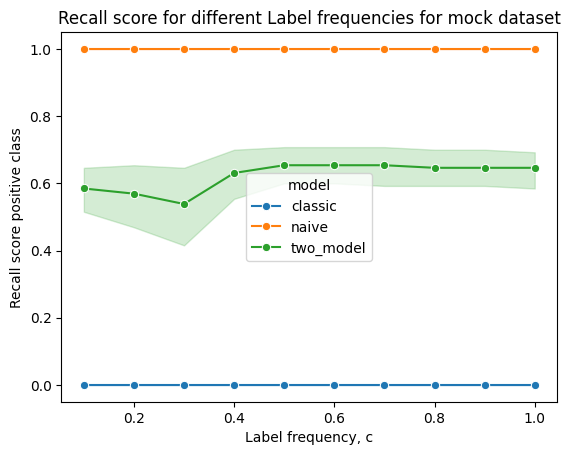

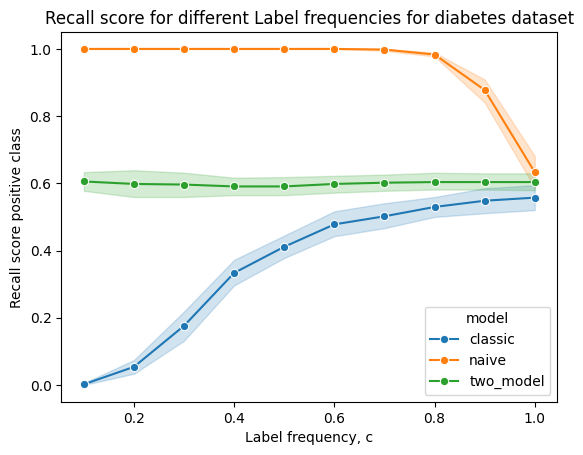

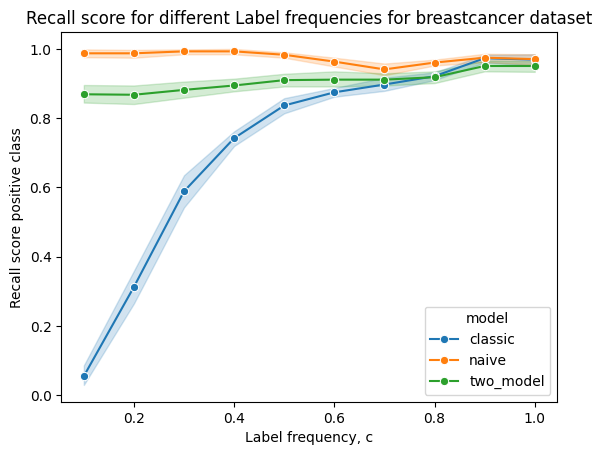

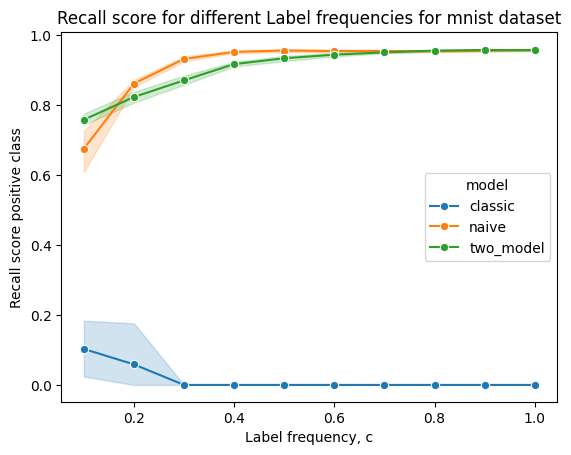

In [77]:
for name,data in zip(datasets,[mock,diabetes,breastcancer,mnist]):
    plt.figure()
    sns.lineplot(data=data, x="c", y="1 recall", hue="model", marker="o")
    plt.title(f"Recall score for different Label frequencies for {name} dataset")
    plt.ylabel(r"Recall score positive class")
    plt.xlabel("Label frequency, c")
    plt.savefig(f"graphs/c_{name}_recall.png")

    # sns.lineplot(data=data, x="c", y="1 precision", hue="model", marker="o", linestyle="--")
    # sns.lineplot(data=data, x="c", y="1 recall", hue="model", marker="o", linestyle=":")


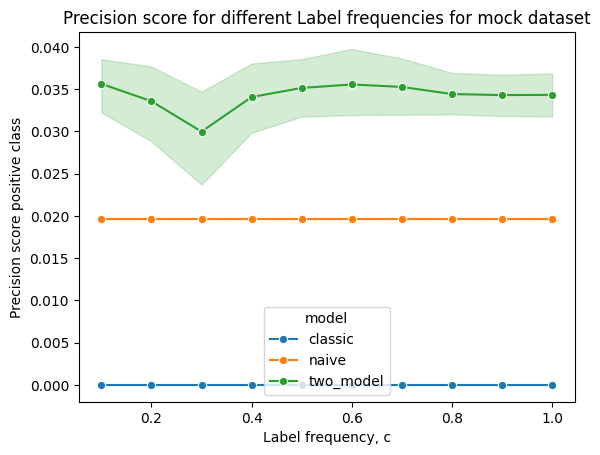

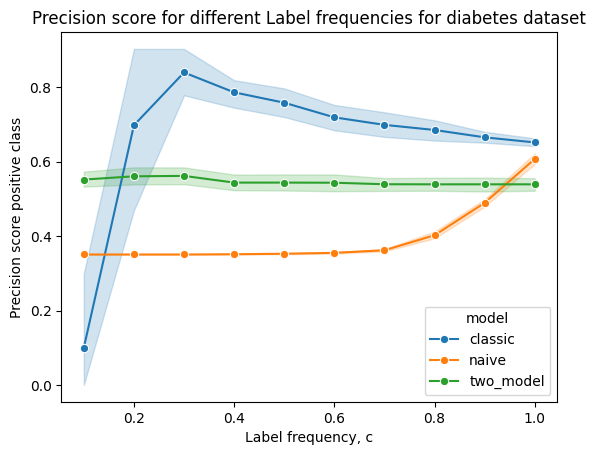

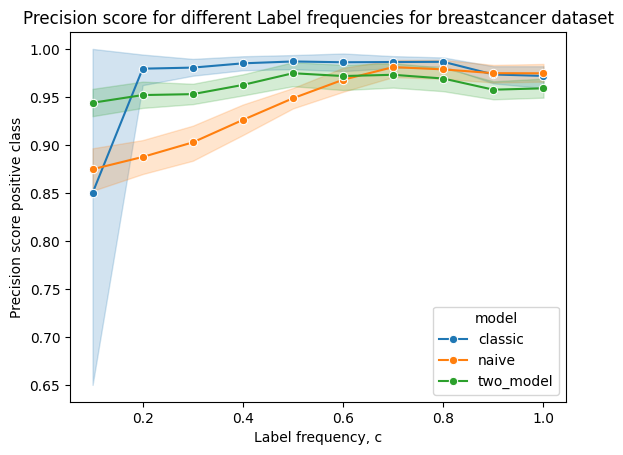

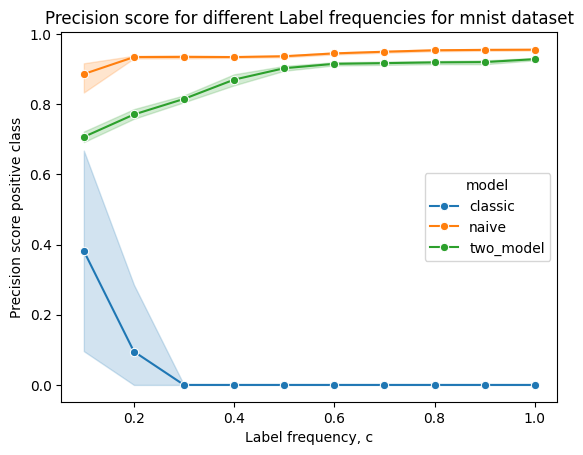

In [78]:
for name,data in zip(datasets,[mock,diabetes,breastcancer,mnist]):
    plt.figure()
    sns.lineplot(data=data, x="c", y="1 precision", hue="model", marker="o")
    plt.title(f"Precision score for different Label frequencies for {name} dataset")
    plt.ylabel(r"Precision score positive class")
    plt.xlabel("Label frequency, c")
    plt.savefig(f"graphs/c_{name}_recall.png")

In [11]:
global DATASETS #Datasets to use for experiments
global MODELS #Classifiers to use for experiments
global ITERS #Amount of iterations per experiment
global STEP_RESULT #Template for each iteration result
global RESULT_COLS #Columns for the result dataframe

global EXPERIMENT_VALUES #Values to use for the current experiment
global EXPERIMENT_ATTR  #Attribute to vary for the current experiment, must equal one of the CONFIG attributes

#2 var experiment_attr_2
global EXPERIMENT_ATTR_2
global EXPERIMENT_VALUES_2

def set_global_vars():
    global DATASETS
    DATASETS = {"mock":get_pd_dataset(name="mock"),"diabetes":get_pd_dataset(name="diabetes"),"breastcancer":get_pd_dataset(name="breastcancer"),"mnist":None}

    global MODELS
    MODELS = {
    "classic": ClassicLogReg(),
    "naive": NaiveLogReg(),
    "two_model": TwoModelLogReg(),
    "oracle": ClassicLogReg()
    }

    global ITERS
    ITERS = np.arange(0,10,1)

    global STEP_RESULT
    STEP_RESULT = set_step_result()
    global RESULT_COLS
    RESULT_COLS = STEP_RESULT.index.tolist()

#Each iteration result template
def set_step_result():
    return pd.Series({
    "accuracy":0.0,
    "0 precision":0.0,
    "1 precision":0.0,
    "0 recall":0.0,
    "1 recall":0.0,
    "0 f1":0.0,
    "1 f1":0.0,
    "0 support":0,
    "1 support":0
}, name="results")

#Evaluate one iteration
def evaluate_step(y_test,y_pred):
    result_series = STEP_RESULT
    result_series["accuracy"] = accuracy_score(y_test, y_pred)
    result_series["0 precision"] = precision_score(y_test, y_pred, pos_label=0)
    result_series["1 precision"] = precision_score(y_test, y_pred, pos_label=1)
    result_series["0 recall"] = recall_score(y_test, y_pred, pos_label=0)
    result_series["1 recall"] = recall_score(y_test, y_pred, pos_label=1)
    result_series["0 f1"] = f1_score(y_test, y_pred, pos_label=0)
    result_series["1 f1"] = f1_score(y_test, y_pred, pos_label=1)
    result_series["0 support"] = sum(y_test == 0)
    result_series["1 support"] = sum(y_test == 1)
    return result_series

#Create the dataframe to store all experiment results, multiindex from all experiment parameters 
def make_test_result_df(sets,columns):    
    X = pd.MultiIndex.from_product(sets,names=columns).to_frame(index=False)
    X["accuracy"] = 0.0
    X["0 precision"] = 0.0
    X["1 precision"] = 0.0
    X["0 recall"] = 0.0
    X["1 recall"] = 0.0
    X["0 f1"] = 0.0
    X["1 f1"] = 0.0
    X["0 support"] = 0
    X["1 support"] = 0

    return X


set_global_vars()

In [45]:
naief = []
klassiek=[]
twee = []
mnist = "mnist"
for label_freq in [0.01,0.1,0.4,0.8,1]:
    print(f"\n Label frequency: {label_freq} \n")
    digits = str(np.random.choice(["1_7", "3_5", "3_8", "5_8", "6_9"], replace=False))
    name = f"mnist_{digits}"
    data = get_pd_dataset(name=name)
    X_train,s_train,X_test,y_test = prepare_and_split_data(data,c=label_freq)
    y_train = CONFIG.true_train_labels
    assert np.abs(label_freq - np.sum(s_train)/np.sum(y_train)) < 0.01, f"Label frequency mismatch: {label_freq} vs {np.sum(s_train)/np.sum(y_train)}"

    clf_c = ClassicLogReg()
    clf_c.fit(X_train,s_train)
    y_pred = clf_c.predict(X_test)
    step_result = evaluate_step(y_test,y_pred)
    klassiek.append(float(step_result["1 f1"]))

    clf_n = NaiveLogReg()
    clf_n.fit(X_train,s_train)
    y_pred = clf_n.predict(X_test)
    step_result = evaluate_step(y_test,y_pred)
    naief.append(float(step_result["1 f1"]))
    print("")
    # clf_t = TwoModelLogReg()
    # clf_t.fit(X_train,s_train)
    # y_pred = clf_t.predict(X_test)
    # step_result = evaluate_step(y_test,y_pred)
    # twee.append(float(step_result["1 f1"]))






 Label frequency: 0.01 



/Users/cas/Documents/naive_pu/data/dataset_helpers.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PU"] = df.loc[df['target'] == 1, 'target'].sample(frac=c, random_state=random_state)
/Users/cas/Documents/naive_pu/data/dataset_helpers.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PU"] = df.loc[df['target'] == 1, 'target'].sample(frac=c, random_state=random_state)


Iteration 0, Loss: 0.5111088156700134 Loss b: 0.5111088156700134, c: 0.6622838311585277


 Label frequency: 0.1 



/Users/cas/Documents/naive_pu/data/dataset_helpers.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PU"] = df.loc[df['target'] == 1, 'target'].sample(frac=c, random_state=random_state)
/Users/cas/Documents/naive_pu/data/dataset_helpers.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PU"] = df.loc[df['target'] == 1, 'target'].sample(frac=c, random_state=random_state)
/Users/cas/miniconda3/envs/naive_pu/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-d

Iteration 0, Loss: 0.5283912420272827 Loss b: 0.5283912420272827, c: 0.6622838311664144


 Label frequency: 0.4 



...

Iteration 0, Loss: 0.5782898664474487 Loss b: 0.5782898664474487, c: 0.6622838312167579


 Label frequency: 0.8 



/Users/cas/Documents/naive_pu/data/dataset_helpers.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PU"] = df.loc[df['target'] == 1, 'target'].sample(frac=c, random_state=random_state)
/Users/cas/Documents/naive_pu/data/dataset_helpers.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PU"] = df.loc[df['target'] == 1, 'target'].sample(frac=c, random_state=random_state)
/Users/cas/miniconda3/envs/naive_pu/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-d

Iteration 0, Loss: 0.6438656449317932 Loss b: 0.6438656449317932, c: 0.6622838355767297


 Label frequency: 1 



/Users/cas/Documents/naive_pu/data/dataset_helpers.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PU"] = df.loc[df['target'] == 1, 'target'].sample(frac=c, random_state=random_state)
/Users/cas/Documents/naive_pu/data/dataset_helpers.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PU"] = df.loc[df['target'] == 1, 'target'].sample(frac=c, random_state=random_state)
/Users/cas/miniconda3/envs/naive_pu/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-d

Iteration 0, Loss: 0.6768119931221008 Loss b: 0.6768119931221008, c: 0.6664667864591267



In [46]:
f1_naief = naief
f1_klassiek = klassiek
# f1_twee = twee
length = np.min([len(f1_naief), len(f1_klassiek)])


df_f1 = pd.DataFrame({
    '1 f1 naive': f1_naief[:length],
    '1 f1 klassiek': f1_klassiek[:length],
    # '1 f1 twee': f1_twee[:length]
})
df_f1

,1 f1 naive,1 f1 klassiek
0,0.286724,0.005827
1,0.828958,0.000000
2,0.954168,0.000000
3,0.963521,0.000000
4,0.997126,0.000000


In [49]:
data = get_pd_dataset(name="mnist")
X_train,s_train,X_test,y_test = prepare_and_split_data(data,c=1)

/Users/cas/Documents/naive_pu/data/dataset_helpers.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PU"] = df.loc[df['target'] == 1, 'target'].sample(frac=c, random_state=random_state)
/Users/cas/Documents/naive_pu/data/dataset_helpers.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PU"] = df.loc[df['target'] == 1, 'target'].sample(frac=c, random_state=random_state)


In [ ]:
clf = ClassicLogReg(tolerance=1e-3)
clf.fit(X_train, s_train)
y_pred = clf.predict(X_test)
step_result = evaluate_step(y_test, y_pred)
step_result

/Users/cas/miniconda3/envs/naive_pu/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


accuracy          0.530658
0 precision       0.530658
1 precision       0.000000
0 recall          1.000000
1 recall          0.000000
0 f1              0.693372
1 f1              0.000000
0 support      1428.000000
1 support      1263.000000
Name: results, dtype: float64

In [61]:
np.random.randint(1000)

571